11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training Data Shape: (60000, 28, 28)
Testing Data Shape: (10000, 28, 28)
Preprocessing Completed!


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Model Summary:



Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 54s 31ms/step - accuracy: 0.9568 - loss: 0.1390 - val_accuracy: 0.9868 - val_loss: 0.0456
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 52s 31ms/step - accuracy: 0.9864 - loss: 0.0440 - val_accuracy: 0.9873 - val_loss: 0.0443
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 53s 31ms/step - accuracy: 0.9903 - loss: 0.0297 - val_accuracy: 0.9912 - val_loss: 0.0344
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 82s 31ms/step - accuracy: 0.9933 - loss: 0.0216 - val_accuracy: 0.9885 - val_loss: 0.0418
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 52s 31ms/step - accuracy: 0.9948 - loss: 0.0158 - val_accuracy: 0.9918 - val_loss: 0.0338
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9911 - loss: 0.0319

Test Accuracy: 0.991100013256073
Test Loss: 0.031882017850875854
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step


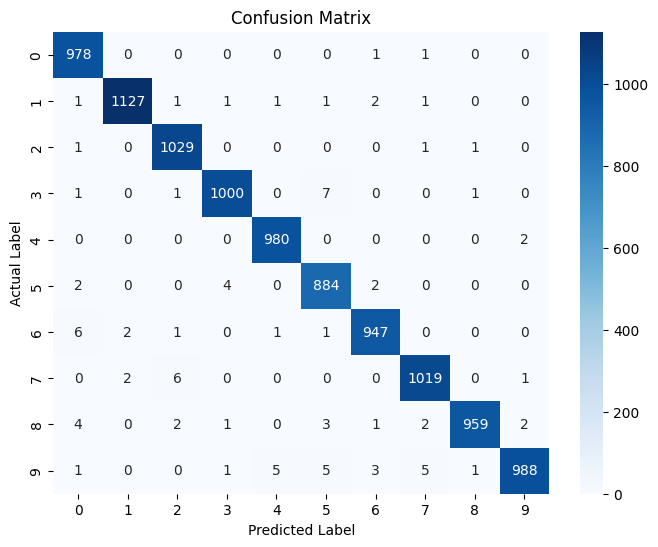


Classification Report:

              precision    recall  f1-score   support

           0       0.98      1.00      0.99       980
           1       1.00      0.99      0.99      1135
           2       0.99      1.00      0.99      1032
           3       0.99      0.99      0.99      1010
           4       0.99      1.00      1.00       982
           5       0.98      0.99      0.99       892
           6       0.99      0.99      0.99       958
           7       0.99      0.99      0.99      1028
           8       1.00      0.98      0.99       974
           9       0.99      0.98      0.99      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000


Model Saved Successfully!
Results Saved Successfully!

Saved Model Loaded Successfully!
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step

Single Sample Prediction
Predicted Label: 7
Actual Label: 7


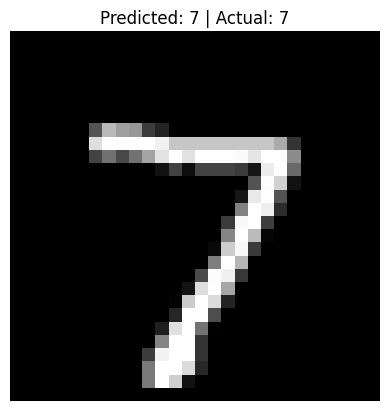

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import pickle

from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.utils import to_categorical

from sklearn.metrics import confusion_matrix, classification_report

# =========================================
# STEP 1: LOAD DATASET
# =========================================
(X_train, y_train), (X_test, y_test) = mnist.load_data()

print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

# =========================================
# STEP 2: DATA PREPROCESSING
# =========================================

# Normalize pixel values (0-255 --> 0-1)
X_train = X_train / 255.0
X_test = X_test / 255.0

# Reshape for CNN
# (samples, height, width, channels)
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

# One-hot encode output labels
y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

print("Preprocessing Completed!")

# =========================================
# STEP 3: DEFINE CNN MODEL
# =========================================
model = Sequential([

    # First Convolution Layer
    Conv2D(
        32,
        (3,3),
        activation='relu',
        input_shape=(28,28,1)
    ),

    # First Pooling Layer
    MaxPooling2D((2,2)),

    # Second Convolution Layer
    Conv2D(
        64,
        (3,3),
        activation='relu'
    ),

    # Second Pooling Layer
    MaxPooling2D((2,2)),

    # Convert 2D --> 1D
    Flatten(),

    # Fully Connected Layer
    Dense(128, activation='relu'),

    # Output Layer
    Dense(10, activation='softmax')
])

# =========================================
# STEP 4: COMPILE MODEL
# =========================================
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("\nModel Summary:\n")
model.summary()

# =========================================
# STEP 5: TRAIN MODEL
# =========================================
history = model.fit(
    X_train,
    y_train_cat,
    epochs=5,
    batch_size=32,
    validation_split=0.1
)

# =========================================
# STEP 6: EVALUATE MODEL
# =========================================
test_loss, test_acc = model.evaluate(X_test, y_test_cat)

print("\nTest Accuracy:", test_acc)
print("Test Loss:", test_loss)

# =========================================
# STEP 7: MAKE PREDICTIONS
# =========================================
y_pred_probs = model.predict(X_test)

# Convert probabilities --> class labels
y_pred = np.argmax(y_pred_probs, axis=1)

# =========================================
# STEP 8: CONFUSION MATRIX
# =========================================
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix")

plt.savefig("confusion_matrix.png")

plt.show()

# =========================================
# STEP 9: CLASSIFICATION REPORT
# =========================================
report = classification_report(y_test, y_pred)

print("\nClassification Report:\n")
print(report)

# Save report
with open("classification_report.txt", "w") as f:
    f.write(report)

# =========================================
# STEP 10: SAVE MODEL
# =========================================
model.save("mnist_cnn_model.h5")

print("\nModel Saved Successfully!")

# =========================================
# STEP 11: SAVE RESULTS
# =========================================
results = {
    "test_accuracy": float(test_acc),
    "test_loss": float(test_loss)
}

with open("results.json", "w") as f:
    json.dump(results, f)

# Save predictions
with open("predictions.pkl", "wb") as f:
    pickle.dump(y_pred, f)

print("Results Saved Successfully!")

# =========================================
# STEP 12: LOAD MODEL AGAIN (OPTIONAL)
# =========================================
loaded_model = load_model("mnist_cnn_model.h5")

print("\nSaved Model Loaded Successfully!")

# =========================================
# STEP 13: SINGLE SAMPLE PREDICTION
# =========================================
sample = X_test[0].reshape(1, 28, 28, 1)

prediction = loaded_model.predict(sample)

predicted_label = np.argmax(prediction)

print("\nSingle Sample Prediction")
print("Predicted Label:", predicted_label)
print("Actual Label:", y_test[0])

# =========================================
# STEP 14: DISPLAY SAMPLE IMAGE
# =========================================
plt.imshow(X_test[0].reshape(28,28), cmap='gray')

plt.title(
    f"Predicted: {predicted_label} | Actual: {y_test[0]}"
)

plt.axis('off')

plt.show()